In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:

print("Structura datelor")
df.info()
print("\n Valori lipsa per coloana")
print(df.isnull().sum().sum())

Structura datelor
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21

Distribuția claselor:
Class
0    284315
1       492
Name: count, dtype: int64

Procentaj fraude:
0.173%


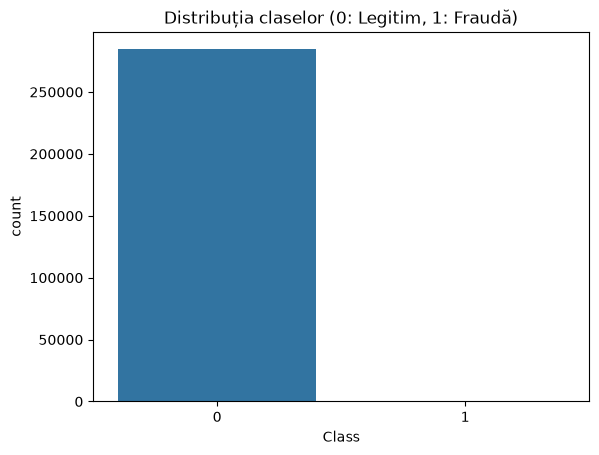

In [3]:
#numaram legitime (0) fraude (1)
class_counts = df['Class'].value_counts()
print("Distribuția claselor:")
print(class_counts)

print("\nProcentaj fraude:")
print(f"{(class_counts[1] / len(df)) * 100:.3f}%")

sns.countplot(x='Class', data=df)
plt.title('Distribuția claselor (0: Legitim, 1: Fraudă)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#f important stratify in acest context

print(f"Dim Train: {X_train.shape}")
print(f"Dim Test: {X_test.shape}")
print(f"Fraude Train: {y_train.sum()}")
print(f"Fraude Test: {y_test.sum()}")

scaler_amount = RobustScaler()
scaler_time = RobustScaler()

X_train['Amount'] = scaler_amount.fit_transform(X_train[['Amount']])
X_train['Time'] = scaler_time.fit_transform(X_train[['Time']])

X_test['Amount'] = scaler_amount.transform(X_test[['Amount']])
X_test['Time'] = scaler_time.transform(X_test[['Time']])

Dimensiune Train: (227845, 30)
Dimensiune Test: (56962, 30)
Fraude in Train: 394
Fraude in Test: 98


RAPORT DE CLASIFICARE (Prag = 0.15)
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997     56864
           1     0.8113    0.8776    0.8431        98

    accuracy                         0.9994     56962
   macro avg     0.9056    0.9386    0.9214     56962
weighted avg     0.9995    0.9994    0.9994     56962



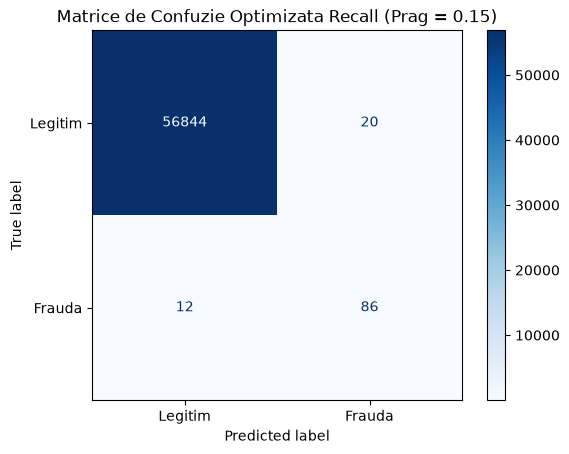

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

rf_model_opt = RandomForestClassifier(
    n_estimators=100, class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf_model_opt.fit(X_train, y_train)

y_probs = rf_model_opt.predict_proba(X_test)[:, 1]
threshold = 0.15
y_pred_opt = (y_probs >= threshold).astype(int)

print(f"RAPORT DE CLASIFICARE (Prag = {threshold})")
print(classification_report(y_test, y_pred_opt, digits=4))

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt, display_labels=["Legitim", "Frauda"]
)
disp.plot(cmap="Blues")
plt.title(f"Matrice de Confuzie Optimizata Recall (Prag = {threshold})")
plt.show()

In [12]:
import joblib

joblib.dump(rf_model_opt, "random_forest_fraud_model.pkl")
print("Modelul a fost salvat cu succes sub numele 'random_forest_fraud_model.pkl'!")

Modelul a fost salvat cu succes sub numele 'random_forest_fraud_model.pkl'!
